In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_damage_national_2010_2025.csv
/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_damage_province_level.csv
/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_damage_district_level.csv
/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_events_timeline.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



# LOAD DATASETS

In [3]:

national_df = pd.read_csv('/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_damage_national_2010_2025.csv')
province_df = pd.read_csv('/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_damage_province_level.csv')
district_df = pd.read_csv('/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_damage_district_level.csv')
events_df = pd.read_csv('/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/pakistan_flood_events_timeline.csv')


In [4]:
print(f"  • National level: {national_df.shape[0]} records, {national_df.shape[1]} features")
print(f"  • Province level: {province_df.shape[0]} records, {province_df.shape[1]} features")
print(f"  • District level: {district_df.shape[0]} records, {district_df.shape[1]} features")
print(f"  • Events timeline: {events_df.shape[0]} major events")


  • National level: 16 records, 30 features
  • Province level: 15 records, 9 features
  • District level: 30 records, 14 features
  • Events timeline: 5 major events


## DATA CLEANING & PREPROCESSING

In [5]:

for df_name, df in [('National', national_df), ('Province', province_df), 
                     ('District', district_df), ('Events', events_df)]:
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"  {df_name}: {missing[missing>0].to_dict()}")

# Clean numeric columns
numeric_cols = ['deaths', 'economic_loss_usd_B', 'people_affected_millions', 
                'houses_destroyed', 'houses_damaged', 'cropland_acres']
for col in numeric_cols:
    if col in national_df.columns:
        national_df[col] = pd.to_numeric(national_df[col], errors='coerce')
    if col in province_df.columns:
        province_df[col] = pd.to_numeric(province_df[col], errors='coerce')
    if col in district_df.columns:
        district_df[col] = pd.to_numeric(district_df[col], errors='coerce')

# Create derived features
national_df['loss_per_person_usd'] = (national_df['economic_loss_usd_B'] * 1e9) / (national_df['people_affected_millions'] * 1e6)
national_df['deaths_per_million_affected'] = (national_df['deaths'] / (national_df['people_affected_millions'] * 1e6)) * 1e6

print("\n Data cleaning complete")


 Data cleaning complete


# ANALYSIS

##  NATIONAL LEVEL TRENDS ANALYSIS

In [6]:
print(f"  • Total Deaths (16 years): {national_df['deaths'].sum():,.0f}")
print(f"  • Total Economic Loss: ${national_df['economic_loss_usd_B'].sum():.2f} Billion")
print(f"  • Total People Affected: {national_df['people_affected_millions'].sum():.2f} Million")
print(f"  • Mega Flood Events: {national_df['is_mega_flood'].sum()}")
print(f"  • Average Rainfall Anomaly: {national_df['rainfall_anomaly_pct'].mean():.1f}%")
print(f"  • Deadliest Year: {national_df.loc[national_df['deaths'].idxmax(), 'year']} ({national_df['deaths'].max():,.0f} deaths)")
print(f"  • Costliest Year: {national_df.loc[national_df['economic_loss_usd_B'].idxmax(), 'year']} (${national_df['economic_loss_usd_B'].max():.1f}B)")


  • Total Deaths (16 years): 8,764
  • Total Economic Loss: $56.24 Billion
  • Total People Affected: 94.00 Million
  • Mega Flood Events: 2
  • Average Rainfall Anomaly: 149.1%
  • Deadliest Year: 2010 (1,985 deaths)
  • Costliest Year: 2022 ($30.0B)


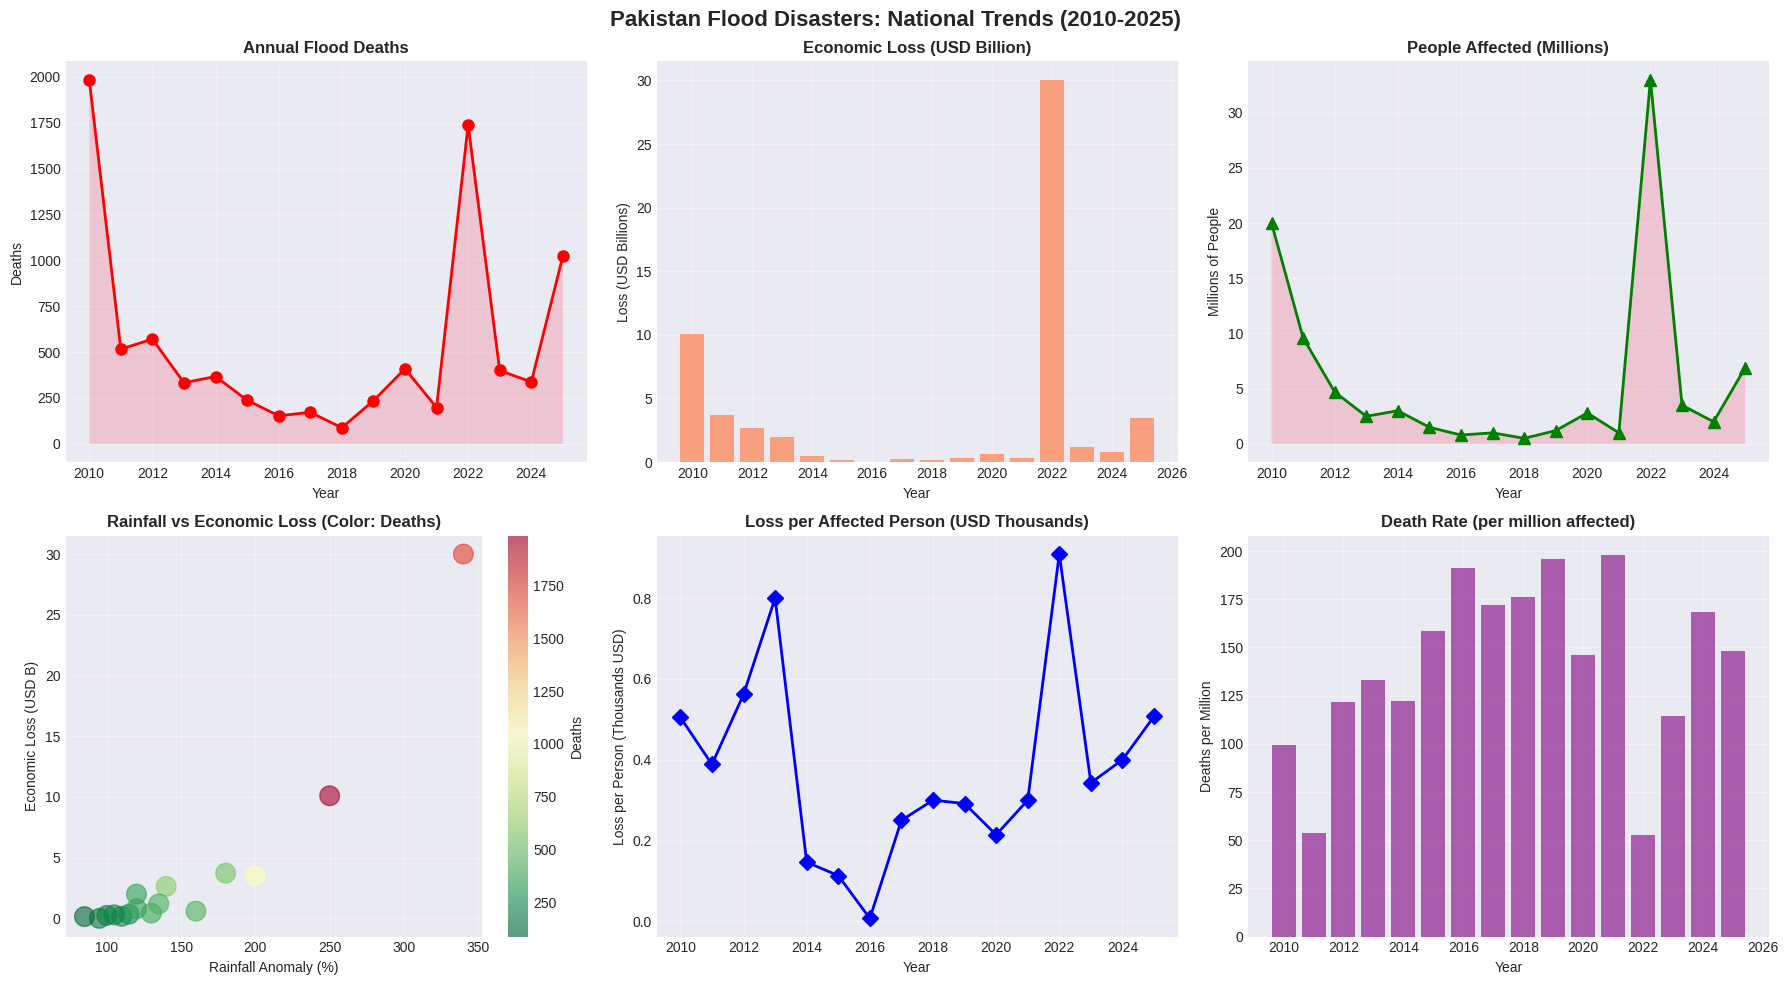

In [7]:


# Create time series plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Pakistan Flood Disasters: National Trends (2010-2025)', fontsize=16, fontweight='bold')

# Deaths over time
axes[0,0].plot(national_df['year'], national_df['deaths'], 'ro-', linewidth=2, markersize=8)
axes[0,0].fill_between(national_df['year'], 0, national_df['deaths'], alpha=0.3)
axes[0,0].set_title('Annual Flood Deaths', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Deaths')
axes[0,0].grid(True, alpha=0.3)

# Economic loss
axes[0,1].bar(national_df['year'], national_df['economic_loss_usd_B'], color='coral', alpha=0.7)
axes[0,1].set_title('Economic Loss (USD Billion)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Loss (USD Billions)')
axes[0,1].grid(True, alpha=0.3)

# People affected
axes[0,2].plot(national_df['year'], national_df['people_affected_millions'], 'g^-', linewidth=2, markersize=8)
axes[0,2].fill_between(national_df['year'], 0, national_df['people_affected_millions'], alpha=0.3)
axes[0,2].set_title('People Affected (Millions)', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Year')
axes[0,2].set_ylabel('Millions of People')
axes[0,2].grid(True, alpha=0.3)

# Rainfall anomaly correlation
scatter = axes[1,0].scatter(national_df['rainfall_anomaly_pct'], national_df['economic_loss_usd_B'], 
                            c=national_df['deaths'], s=200, cmap='RdYlGn_r', alpha=0.6)
axes[1,0].set_xlabel('Rainfall Anomaly (%)')
axes[1,0].set_ylabel('Economic Loss (USD B)')
axes[1,0].set_title('Rainfall vs Economic Loss (Color: Deaths)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[1,0], label='Deaths')
axes[1,0].grid(True, alpha=0.3)

# Loss per person
axes[1,1].plot(national_df['year'], national_df['loss_per_person_usd'] / 1000, 'bD-', linewidth=2, markersize=8)
axes[1,1].set_title('Loss per Affected Person (USD Thousands)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Loss per Person (Thousands USD)')
axes[1,1].grid(True, alpha=0.3)

# Death rate per million affected
axes[1,2].bar(national_df['year'], national_df['deaths_per_million_affected'], color='purple', alpha=0.6)
axes[1,2].set_title('Death Rate (per million affected)', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Year')
axes[1,2].set_ylabel('Deaths per Million')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##  PROVINCE-LEVEL ANALYSIS

In [8]:


# Province summary
province_summary = province_df.groupby('province').agg({
    'deaths': 'sum',
    'economic_loss_usd_B': 'sum',
    'houses_destroyed': 'sum',
    'houses_damaged': 'sum'
}).round(2).sort_values('deaths', ascending=False)

print("\n Province-wise Total Impact (2010-2025):")
print(province_summary)


 Province-wise Total Impact (2010-2025):
                  deaths  economic_loss_usd_B  houses_destroyed  \
province                                                          
KPK                 2413                 10.1            485000   
Sindh               1322                 18.7           1471000   
Punjab               802                 10.4            403000   
Balochistan          575                  7.6            386000   
Gilgit-Baltistan      76                  0.5               481   

                  houses_damaged  
province                          
KPK                       340000  
Sindh                    1495000  
Punjab                    441000  
Balochistan               400000  
Gilgit-Baltistan            1246  


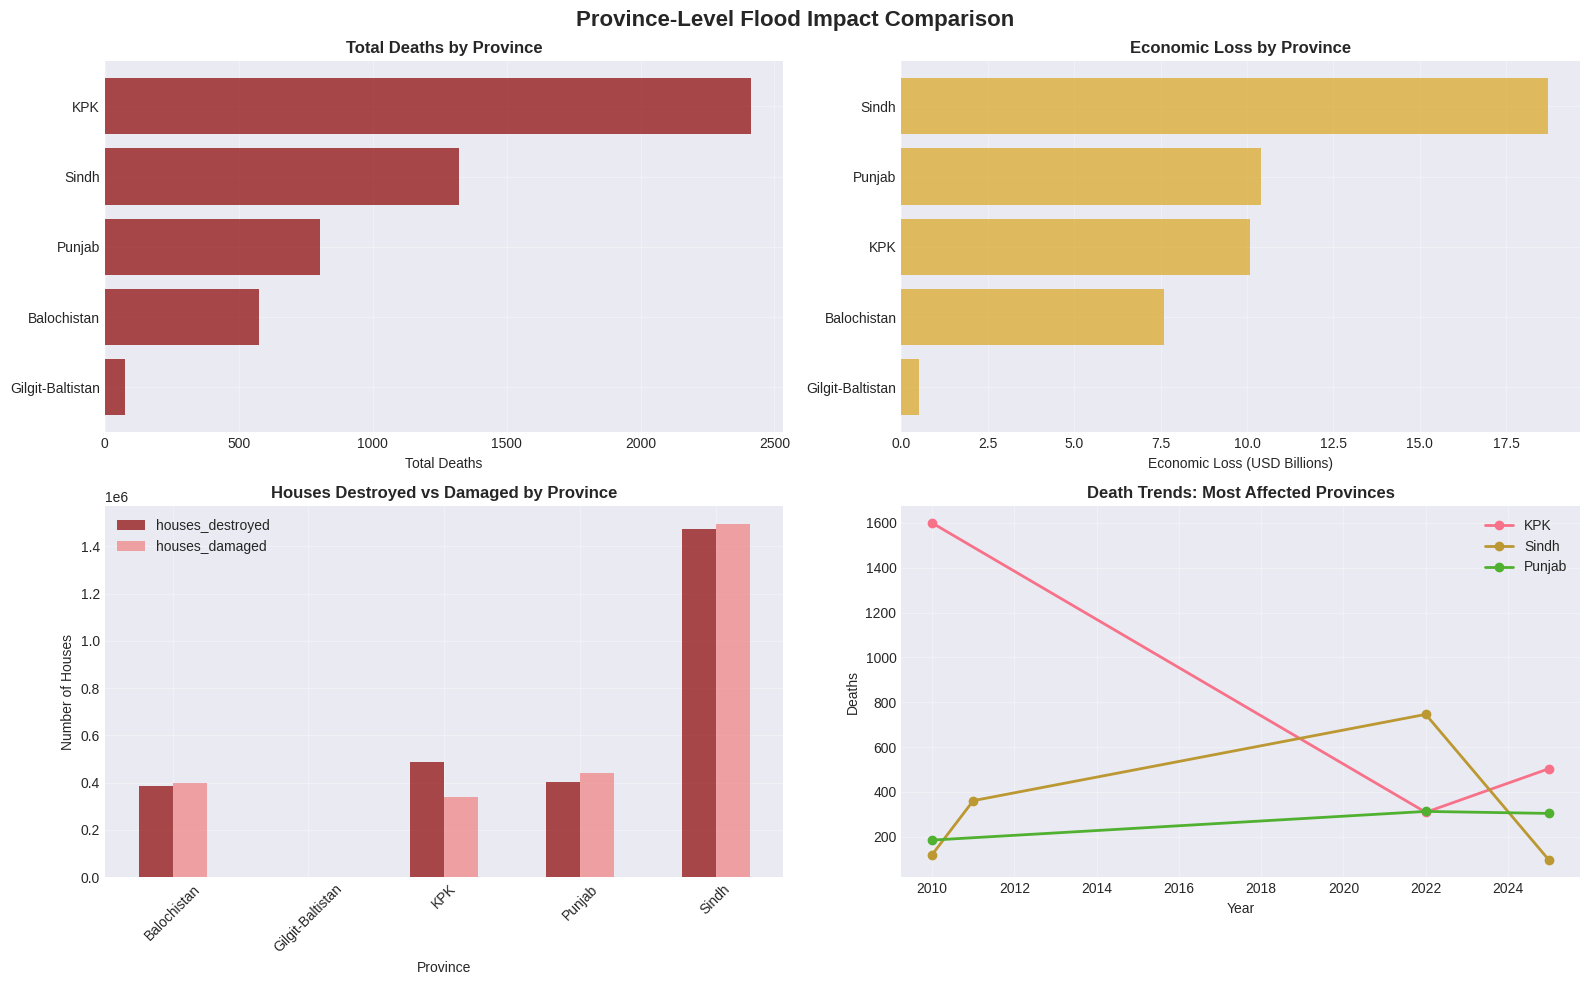

In [9]:


# Create province comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Province-Level Flood Impact Comparison', fontsize=16, fontweight='bold')

# Deaths by province
province_deaths = province_df.groupby('province')['deaths'].sum().sort_values()
axes[0,0].barh(province_deaths.index, province_deaths.values, color='darkred', alpha=0.7)
axes[0,0].set_xlabel('Total Deaths')
axes[0,0].set_title('Total Deaths by Province', fontsize=12, fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Economic loss by province
province_loss = province_df.groupby('province')['economic_loss_usd_B'].sum().sort_values()
axes[0,1].barh(province_loss.index, province_loss.values, color='goldenrod', alpha=0.7)
axes[0,1].set_xlabel('Economic Loss (USD Billions)')
axes[0,1].set_title('Economic Loss by Province', fontsize=12, fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# Houses destroyed vs damaged
province_houses = province_df.groupby('province')[['houses_destroyed', 'houses_damaged']].sum()
province_houses.plot(kind='bar', ax=axes[1,0], color=['darkred', 'lightcoral'], alpha=0.7)
axes[1,0].set_title('Houses Destroyed vs Damaged by Province', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Province')
axes[1,0].set_ylabel('Number of Houses')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].tick_params(axis='x', rotation=45)

# Yearly trend by province (top 3 provinces)
top_provinces = province_df.groupby('province')['deaths'].sum().nlargest(3).index
for province in top_provinces:
    province_data = province_df[province_df['province'] == province]
    axes[1,1].plot(province_data['year'], province_data['deaths'], 'o-', linewidth=2, markersize=6, label=province)
axes[1,1].set_title('Death Trends: Most Affected Provinces', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Deaths')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##   DISTRICT-LEVEL GEOSPATIAL & SEVERITY ANALYSIS

In [10]:




print(f"\n District-Level Statistics:")
print(f"  • Total Districts Analyzed: {district_df['district'].nunique()}")
print(f"  • Provinces Covered: {district_df['province'].unique()}")
print(f"  • Severity Distribution:")
severity_dist = district_df['severity'].value_counts()
for severity, count in severity_dist.items():
    print(f"    - {severity}: {count} districts")

print(f"\n  • Flood Type Distribution:")
floodtype_dist = district_df['flood_type'].value_counts()
for ftype, count in floodtype_dist.items():
    print(f"    - {ftype}: {count} districts")



 District-Level Statistics:
  • Total Districts Analyzed: 21
  • Provinces Covered: ['KPK' 'Punjab' 'Sindh' 'Balochistan' 'Gilgit-Baltistan']
  • Severity Distribution:
    - Severe: 13 districts
    - Catastrophic: 12 districts
    - Moderate: 5 districts

  • Flood Type Distribution:
    - Riverine: 14 districts
    - Flash Flood: 8 districts
    - Monsoon + Riverine: 3 districts
    - Riverine Inundation: 1 districts
    - Flash Flood + Riverine: 1 districts
    - Riverine (Indus/Chenab): 1 districts
    - Riverine (Sutlej): 1 districts
    - GLOF: 1 districts


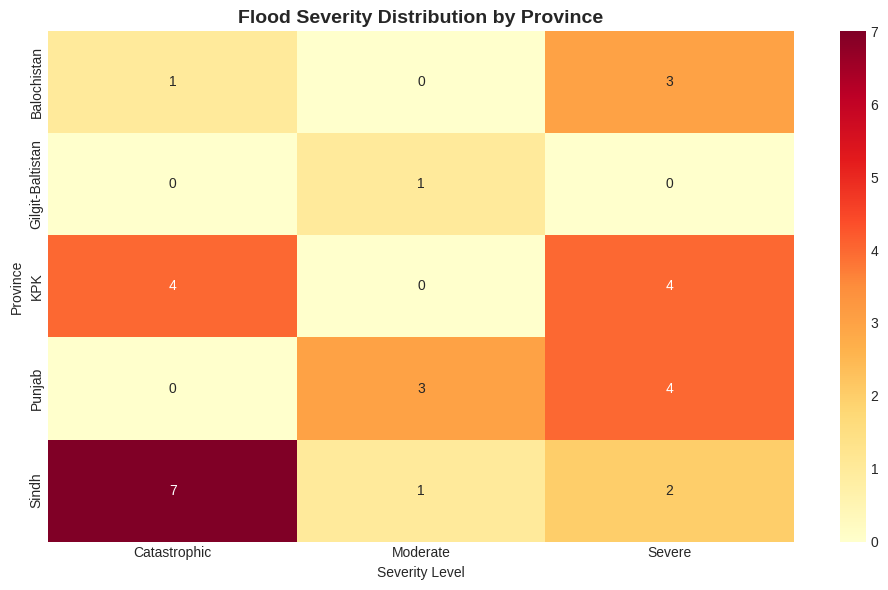

In [11]:
# Heatmap of severity by province
severity_matrix = pd.crosstab(district_df['province'], district_df['severity'])
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(severity_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Flood Severity Distribution by Province', fontsize=14, fontweight='bold')
ax.set_xlabel('Severity Level')
ax.set_ylabel('Province')
plt.tight_layout()
plt.show()


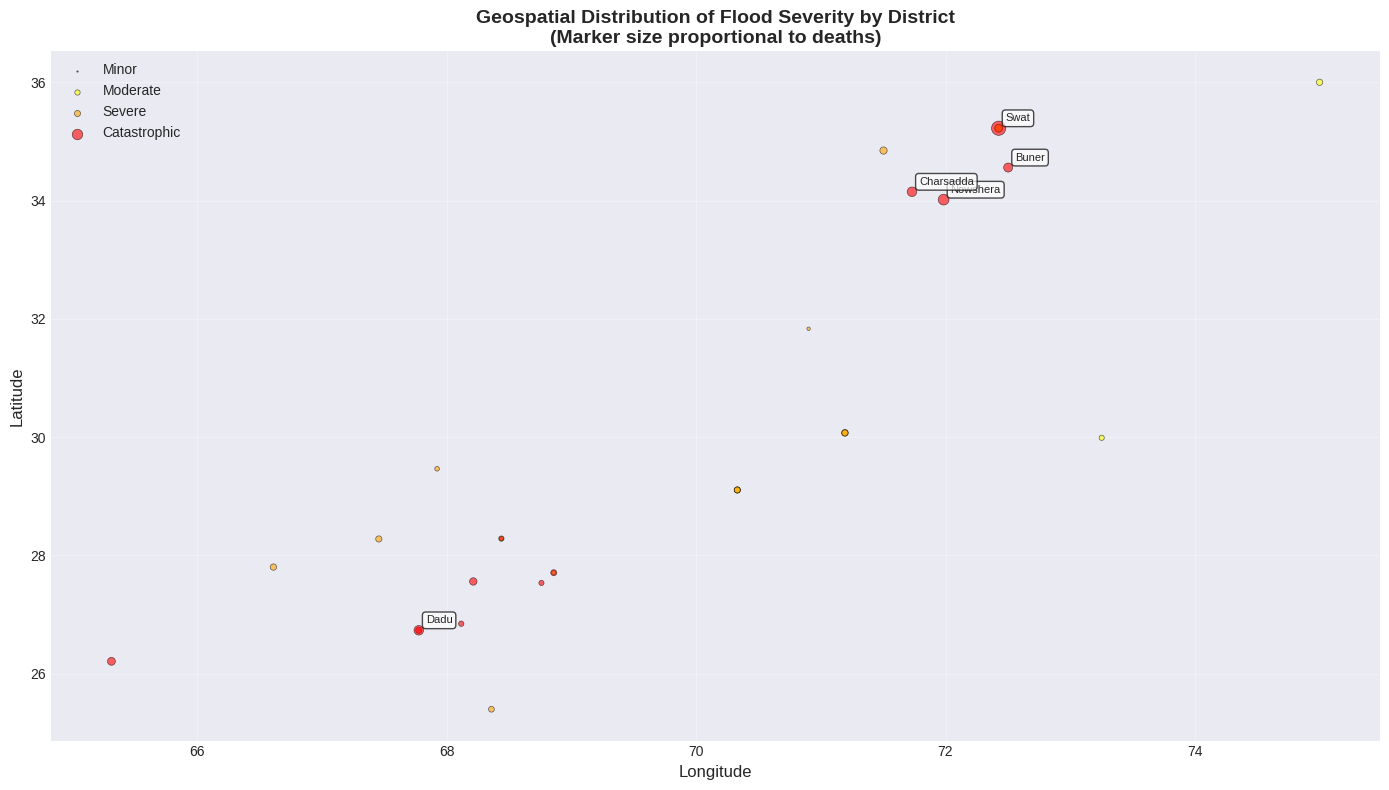

In [12]:


# Create interactive map for district-level data (static version)
fig, ax = plt.subplots(figsize=(14, 8))

# Color map for severity
severity_colors = {'Minor': 'green', 'Moderate': 'yellow', 'Severe': 'orange', 'Catastrophic': 'red'}
for severity, color in severity_colors.items():
    subset = district_df[district_df['severity'] == severity]
    scatter = ax.scatter(subset['longitude'], subset['latitude'], 
                        s=subset['deaths']/2, c=color, alpha=0.6, 
                        label=severity, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Geospatial Distribution of Flood Severity by District\n(Marker size proportional to deaths)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Add labels for worst-hit districts
worst_districts = district_df.nlargest(5, 'deaths')
for idx, row in worst_districts.iterrows():
    ax.annotate(row['district'], (row['longitude'], row['latitude']), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

##  Top 10 worst districts

In [13]:
print("\n TOP 10 WORST-AFFECTED DISTRICTS:")
top_districts = district_df.nlargest(10, 'deaths')[['district', 'province', 'year', 'deaths', 
                                                      'people_affected', 'cropland_acres', 'severity']]
print(top_districts.to_string(index=False))


 TOP 10 WORST-AFFECTED DISTRICTS:
 district    province  year  deaths  people_affected  cropland_acres     severity
     Swat         KPK  2010     210          1100000          400000 Catastrophic
 Nowshera         KPK  2010     120           850000          300000 Catastrophic
Charsadda         KPK  2010      95           720000          250000 Catastrophic
     Dadu       Sindh  2022      95          1200000         1000000 Catastrophic
    Buner         KPK  2025      85           280000          120000 Catastrophic
  Lasbela Balochistan  2022      65           320000          280000 Catastrophic
     Swat         KPK  2025      65           220000          100000       Severe
  Larkana       Sindh  2011      58           900000          600000 Catastrophic
     Swat         KPK  2022      55           400000          200000       Severe
   Bajaur         KPK  2025      55           190000           90000       Severe


##  FLOOD EVENTS TIMELINE ANALYSIS


 Major Flood Events (2010-2025):
              event_name  year                                                                           trigger  un_appeal_usd_M  international_aid_received_usd_M
        2010 Super Flood  2010                             Record monsoon rains; KP/Punjab rivers exceeded banks              460                              1900
       2011 Sindh Floods  2011                 High-intensity rainfall on eastern Indus; separate from 2010 path              357                               450
     2012 Monsoon Floods  2012                                    Monsoon rains; KP and southern Punjab affected              150                               180
2022 Pakistan Mega Flood  2022 8 monsoon cycles; glacial melt; back-to-back heatwaves; Sindh 784% above avg rain              816                              1200
   2025 Punjab-KP Floods  2025                Record monsoon; Indian dam releases; glacial melt; KP flash floods              500                 

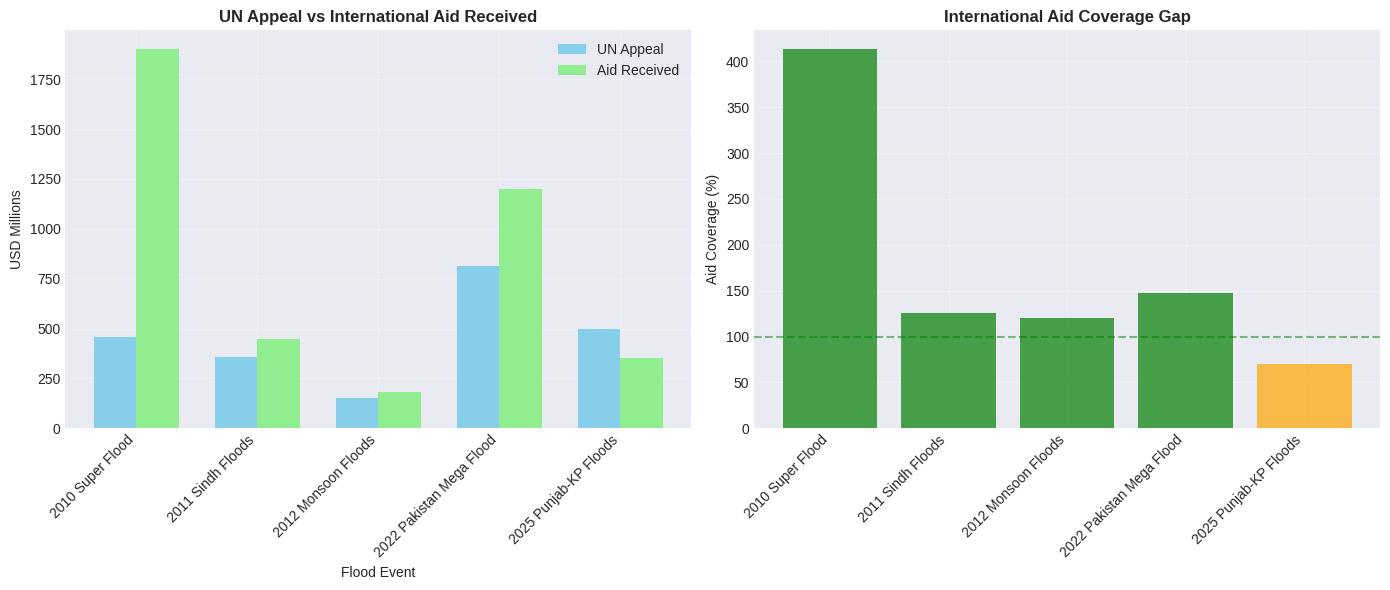

In [14]:


print("\n Major Flood Events (2010-2025):")
print(events_df[['event_name', 'year', 'trigger', 'un_appeal_usd_M', 'international_aid_received_usd_M']].to_string(index=False))

# Aid gap analysis
events_df['aid_gap_usd_M'] = events_df['un_appeal_usd_M'] - events_df['international_aid_received_usd_M']
events_df['aid_coverage_pct'] = (events_df['international_aid_received_usd_M'] / events_df['un_appeal_usd_M']) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Aid appeal vs received
x = np.arange(len(events_df['event_name']))
width = 0.35
axes[0].bar(x - width/2, events_df['un_appeal_usd_M'], width, label='UN Appeal', color='skyblue')
axes[0].bar(x + width/2, events_df['international_aid_received_usd_M'], width, label='Aid Received', color='lightgreen')
axes[0].set_xlabel('Flood Event')
axes[0].set_ylabel('USD Millions')
axes[0].set_title('UN Appeal vs International Aid Received', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(events_df['event_name'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Aid coverage percentage
colors = ['red' if x < 50 else 'orange' if x < 80 else 'green' for x in events_df['aid_coverage_pct']]
axes[1].bar(events_df['event_name'], events_df['aid_coverage_pct'], color=colors, alpha=0.7)
axes[1].axhline(y=100, color='green', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Aid Coverage (%)')
axes[1].set_title('International Aid Coverage Gap', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(events_df['event_name'], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##   CORRELATION ANALYSIS & INSIGHTS

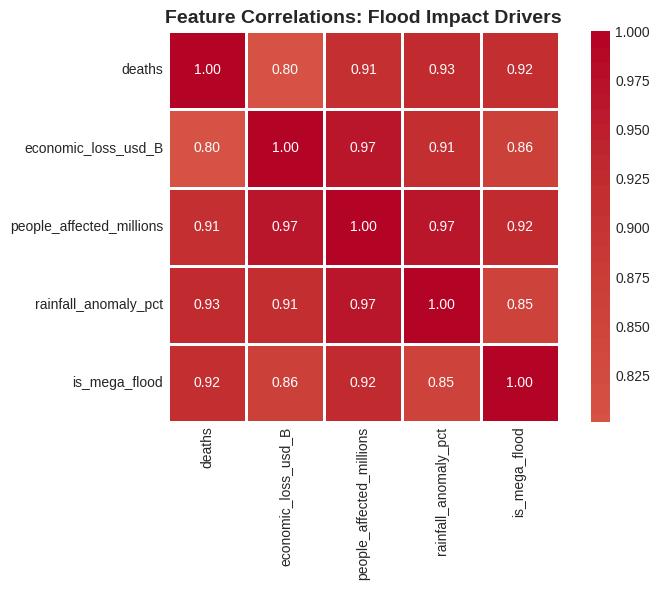


 Key Correlation Insights:
   Rainfall Anomaly vs Economic Loss: 0.91
   Rainfall Anomaly vs People Affected: 0.97
   Mega Flood vs Economic Loss: 0.86


In [15]:


# Correlation matrix for national data
corr_cols = ['deaths', 'economic_loss_usd_B', 'people_affected_millions', 
             'rainfall_anomaly_pct', 'is_mega_flood']
corr_matrix = national_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, ax=ax)
ax.set_title('Feature Correlations: Flood Impact Drivers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Key Correlation Insights:")
print(f"   Rainfall Anomaly vs Economic Loss: {corr_matrix.loc['rainfall_anomaly_pct', 'economic_loss_usd_B']:.2f}")
print(f"   Rainfall Anomaly vs People Affected: {corr_matrix.loc['rainfall_anomaly_pct', 'people_affected_millions']:.2f}")
print(f"   Mega Flood vs Economic Loss: {corr_matrix.loc['is_mega_flood', 'economic_loss_usd_B']:.2f}")


## Flood Impact

In [16]:



fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Cropland Loss by District', 'Houses Impact Distribution',
                    'Severity Timeline', 'Flood Type Impact'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'scatter'}, {'type': 'pie'}]]
)

# Cropland loss by district (top 10)
top_cropland = district_df.nlargest(10, 'cropland_acres')
fig.add_trace(go.Bar(x=top_cropland['district'], y=top_cropland['cropland_acres'], 
                     marker_color='green', name='Cropland Loss'), row=1, col=1)

# Houses distribution
houses_summary = district_df[['houses_destroyed', 'houses_damaged']].sum()
fig.add_trace(go.Bar(x=['Destroyed', 'Damaged'], y=[houses_summary['houses_destroyed'], 
                                                     houses_summary['houses_damaged']],
                     marker_color=['darkred', 'salmon'], name='Houses'), row=1, col=2)

# Severity over years
severity_yearly = district_df.groupby(['year', 'severity']).size().unstack(fill_value=0)
for severity in severity_yearly.columns:
    fig.add_trace(go.Scatter(x=severity_yearly.index, y=severity_yearly[severity], 
                             mode='lines+markers', name=severity), row=2, col=1)

# Flood type impact (deaths by type)
floodtype_deaths = district_df.groupby('flood_type')['deaths'].sum()
fig.add_trace(go.Pie(labels=floodtype_deaths.index, values=floodtype_deaths.values, 
                     hole=0.3, name='Flood Type'), row=2, col=2)

fig.update_layout(height=800, showlegend=True, title_text="Comprehensive Flood Impact Dashboard")
fig.update_xaxes(tickangle=45)
fig.show()


##   TIME SERIES FORECASTING 


 Trend Analysis (2010-2025):
  • Death Trend: -9.0 deaths/year (p-value: 0.7771)
  • Economic Loss Trend: 0.15 Billion USD/year (p-value: 0.7280)
  • Warning: Significant increasing trend in both metrics!


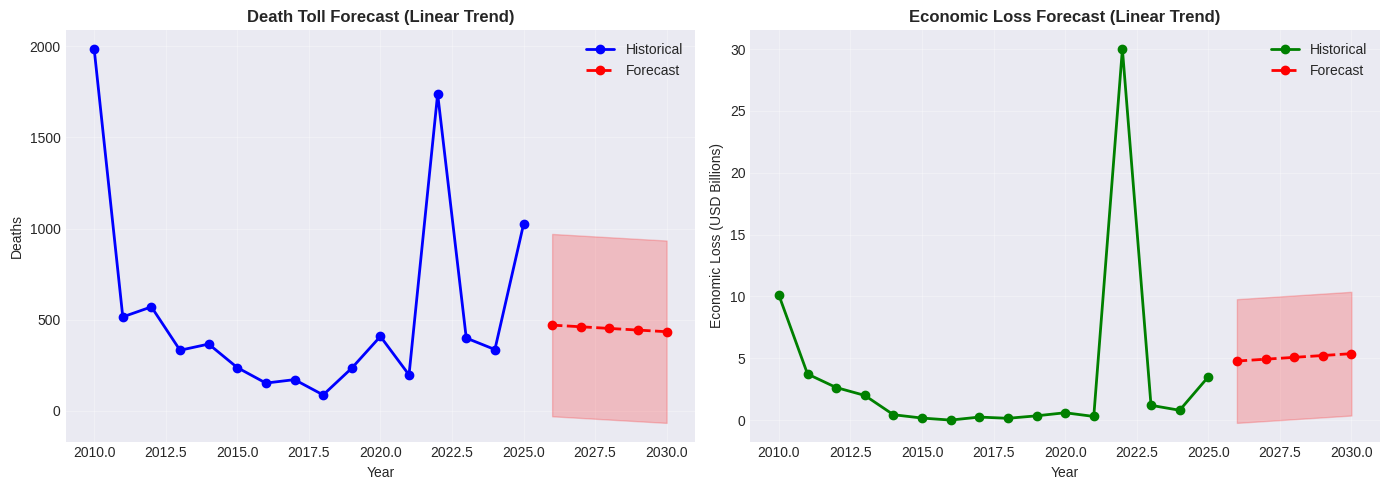

In [17]:


from scipy import stats

# Detect trends using linear regression
years = national_df['year'].values
deaths = national_df['deaths'].values
loss = national_df['economic_loss_usd_B'].values

death_slope, death_intercept, death_r, death_p, death_std_err = stats.linregress(years, deaths)
loss_slope, loss_intercept, loss_r, loss_p, loss_std_err = stats.linregress(years, loss)

print(f"\n Trend Analysis (2010-2025):")
print(f"  • Death Trend: {death_slope:.1f} deaths/year (p-value: {death_p:.4f})")
print(f"  • Economic Loss Trend: {loss_slope:.2f} Billion USD/year (p-value: {loss_p:.4f})")
print(f"  • Warning: Significant increasing trend in both metrics!")

# Forecast next 5 years (simple linear extrapolation)
future_years = np.array([2026, 2027, 2028, 2029, 2030])
forecast_deaths = death_slope * future_years + death_intercept
forecast_loss = loss_slope * future_years + loss_intercept

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(years, deaths, 'bo-', label='Historical', linewidth=2)
axes[0].plot(future_years, forecast_deaths, 'r--o', label='Forecast', linewidth=2)
axes[0].fill_between(future_years, forecast_deaths - 500, forecast_deaths + 500, alpha=0.2, color='red')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deaths')
axes[0].set_title('Death Toll Forecast (Linear Trend)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(years, loss, 'go-', label='Historical', linewidth=2)
axes[1].plot(future_years, forecast_loss, 'r--o', label='Forecast', linewidth=2)
axes[1].fill_between(future_years, forecast_loss - 5, forecast_loss + 5, alpha=0.2, color='red')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Economic Loss (USD Billions)')
axes[1].set_title('Economic Loss Forecast (Linear Trend)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
!pip install pingouin -q

# MODEL 

In [19]:


from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingRegressor, IsolationForest
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, r2_score,
    mean_absolute_error, mean_squared_error,
    silhouette_score
)
from sklearn.neighbors import NearestNeighbors


import xgboost as xgb


from prophet import Prophet


from scipy.stats import pearsonr
import statsmodels.api as sm


plt.style.use("ggplot")
sns.set_theme(style="darkgrid")




base = "/kaggle/input/datasets/alitaqishah/pakistan-flood-disasters-dataset-20102025/"

national_df = pd.read_csv(base + "pakistan_flood_damage_national_2010_2025.csv")
province_df = pd.read_csv(base + "pakistan_flood_damage_province_level.csv")
district_df = pd.read_csv(base + "pakistan_flood_damage_district_level.csv")
events_df   = pd.read_csv(base + "pakistan_flood_events_timeline.csv")



national_ml = national_df.copy()
province_ml = province_df.copy()
district_ml = district_df.copy()

# ---------- National ----------
national_ml["year_since_2010"] = national_ml["year"] - 2010
national_ml["prev_year_loss"] = national_ml["economic_loss_usd_B"].shift(1)
national_ml["prev_year_deaths"] = national_ml["deaths"].shift(1)
national_ml["rainfall_ma3"] = national_ml["rainfall_anomaly_pct"].rolling(3).mean()

national_ml["loss_per_person"] = (
    national_ml["economic_loss_usd_B"] * 1e9
) / (national_ml["people_affected_millions"] * 1e6 + 1)

# ---------- Province ----------
province_ml["damage_intensity"] = (
    province_ml["economic_loss_usd_B"] /
    (province_ml["houses_destroyed"] + 1)
)

# ---------- District ----------
district_ml["total_houses"] = (
    district_ml["houses_destroyed"] +
    district_ml["houses_damaged"]
)

district_ml["damage_per_person"] = (
    district_ml["total_houses"] /
    (district_ml["people_affected"] + 1)
)

district_ml["deaths_per_thousand"] = (
    district_ml["deaths"] /
    ((district_ml["people_affected"] / 1000) + 1)
)

# Encoding
enc1 = LabelEncoder()
enc2 = LabelEncoder()
enc3 = LabelEncoder()

district_ml["severity_encoded"] = enc1.fit_transform(district_ml["severity"])
district_ml["flood_type_encoded"] = enc2.fit_transform(district_ml["flood_type"])
district_ml["province_encoded"] = enc3.fit_transform(district_ml["province"])

print(" Data preprocessing complete")


 Data preprocessing complete


## FLOOD SEVERITY CLASSIFICATION

In [20]:

features = [
    "deaths", "houses_destroyed", "houses_damaged",
    "people_affected", "cropland_acres",
    "flood_type_encoded", "province_encoded"
]

In [21]:


X = district_ml[features].fillna(0)
y = district_ml["severity_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_s, y_train)

xgb_cls = xgb.XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="mlogloss",
    random_state=42
)
xgb_cls.fit(X_train_s, y_train)

pred_rf = rf.predict(X_test_s)
pred_xgb = xgb_cls.predict(X_test_s)

print(f"Random Forest Accuracy : {accuracy_score(y_test, pred_rf):.3f}")
print(f"XGBoost Accuracy       : {accuracy_score(y_test, pred_xgb):.3f}")

# Importance
imp = pd.DataFrame({
    "Feature": features,
    "RF": rf.feature_importances_,
    "XGB": xgb_cls.feature_importances_
}).sort_values("RF", ascending=False)

print("\nTop Features:")
print(imp.head())

Random Forest Accuracy : 1.000
XGBoost Accuracy       : 0.875

Top Features:
            Feature        RF       XGB
2    houses_damaged  0.240384  0.424361
1  houses_destroyed  0.194866  0.203558
0            deaths  0.182963  0.185256
3   people_affected  0.156816  0.042368
4    cropland_acres  0.110823  0.047308


##  ECONOMIC LOSS REGRESSION

In [22]:


reg_features = [
    "year_since_2010",
    "rainfall_anomaly_pct",
    "people_affected_millions",
    "prev_year_loss",
    "rainfall_ma3"
]

reg_df = national_ml.dropna(subset=reg_features)

Xr = reg_df[reg_features]
yr = reg_df["economic_loss_usd_B"]

scaler_r = StandardScaler()
Xr_s = scaler_r.fit_transform(Xr)

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoost": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, random_state=42)
}

results = []

tscv = TimeSeriesSplit(n_splits=3)

for name, model in models.items():

    cv_scores = []

    for train_idx, val_idx in tscv.split(Xr_s):
        Xtr, Xval = Xr_s[train_idx], Xr_s[val_idx]
        ytr, yval = yr.iloc[train_idx], yr.iloc[val_idx]

        model.fit(Xtr, ytr)
        pred = model.predict(Xval)

        cv_scores.append(r2_score(yval, pred))

    model.fit(Xr_s, yr)
    pred_full = model.predict(Xr_s)

    results.append({
        "Model": name,
        "Train_R2": r2_score(yr, pred_full),
        "CV_R2": np.mean(cv_scores),
        "MAE": mean_absolute_error(yr, pred_full),
        "RMSE": np.sqrt(mean_squared_error(yr, pred_full))
    })

results_df = pd.DataFrame(results).sort_values("CV_R2", ascending=False)
print(results_df.round(3))

best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
best_model.fit(Xr_s, yr)

print(f"\n Best Generalizable Model: {best_name}")

           Model  Train_R2    CV_R2    MAE   RMSE
2   RandomForest     0.867  -12.556  1.083  2.750
1          Ridge     0.976  -19.308  0.940  1.180
3  GradientBoost     1.000  -20.820  0.001  0.001
4        XGBoost     1.000 -189.919  0.000  0.001
0         Linear     0.997 -231.910  0.267  0.398

 Best Generalizable Model: RandomForest


##  DISTRICT CLUSTERING

In [23]:


cluster_cols = [
    "deaths",
    "houses_destroyed",
    "people_affected",
    "cropland_acres",
    "damage_per_person",
    "deaths_per_thousand"
]

Xc = district_ml[cluster_cols].fillna(0)
Xc_s = StandardScaler().fit_transform(Xc)

scores = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xc_s)
    scores.append(silhouette_score(Xc_s, labels))

best_k = list(k_values)[np.argmax(scores)]

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
district_ml["cluster"] = kmeans.fit_predict(Xc_s)

print(f"Optimal Clusters: {best_k}")

summary = district_ml.groupby("cluster")[[
    "deaths", "people_affected", "cropland_acres"
]].mean().round(1)

print(summary)

Optimal Clusters: 4
         deaths  people_affected  cropland_acres
cluster                                         
0          35.2         341250.0        286875.0
1         141.7         890000.0        316666.7
2          46.6         731428.6        570000.0
3          61.5         185000.0         87500.0


##  ANOMALY DETECTION

In [24]:


anom_cols = [
    "deaths",
    "economic_loss_usd_B",
    "people_affected_millions",
    "rainfall_anomaly_pct"
]

Xa = national_ml[anom_cols].fillna(0)

iso = IsolationForest(contamination=0.2, random_state=42)
labels = iso.fit_predict(Xa)

national_ml["anomaly"] = labels
years = national_ml[national_ml["anomaly"] == -1]["year"].tolist()

print("Anomalous Years:", years)

Anomalous Years: [2010, 2022, 2025]


##  PROPHET FORECAST

In [25]:


prophet_df = national_df[["year", "deaths"]].copy()
prophet_df.columns = ["ds", "y"]
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"], format="%Y")

try:
    m = Prophet()
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=5, freq="Y")
    forecast = m.predict(future)

    future_only = forecast.tail(5)[["ds", "yhat"]]
    future_only["ds"] = future_only["ds"].dt.year

    print(future_only.round(0).to_string(index=False))

except:
    print("Prophet forecast skipped")

13:47:10 - cmdstanpy - INFO - Chain [1] start processing
13:47:10 - cmdstanpy - INFO - Chain [1] done processing


  ds   yhat
2025  124.0
2026    1.0
2027 -128.0
2028  205.0
2029   88.0


##  GEOSPATIAL ANALYSIS

In [26]:

coords = district_ml[["longitude", "latitude"]].values
deaths = district_ml["deaths"].values

nbrs = NearestNeighbors(n_neighbors=4).fit(coords)
_, idx = nbrs.kneighbors(coords)

W = np.zeros((len(coords), len(coords)))

for i in range(len(coords)):
    for j in idx[i][1:]:
        W[i, j] = 1

z = (deaths - deaths.mean()) / (deaths.std() + 1e-9)
Wz = W @ z

morans_i = (len(z) / W.sum()) * (z @ Wz) / (z @ z)

print(f"Moran's I = {morans_i:.3f}")

Moran's I = 0.275


## CAUSAL INFERENCE 

In [27]:


causal = national_ml[[
    "rainfall_anomaly_pct",
    "economic_loss_usd_B",
    "people_affected_millions"
]].dropna()

# Pearson
r, p = pearsonr(
    causal["rainfall_anomaly_pct"],
    causal["economic_loss_usd_B"]
)

print(f"Pearson r = {r:.3f}, p = {p:.4f}")

# Controlled Regression
Xcau = causal[["rainfall_anomaly_pct", "people_affected_millions"]]
Xcau = sm.add_constant(Xcau)

model = sm.OLS(
    causal["economic_loss_usd_B"],
    Xcau
).fit()

coef = model.params["rainfall_anomaly_pct"]
pval = model.pvalues["rainfall_anomaly_pct"]

print(f"Controlled Effect of Rainfall = {coef:.3f}")
print(f"P-value = {pval:.4f}")


Pearson r = 0.914, p = 0.0000
Controlled Effect of Rainfall = -0.034
P-value = 0.2930
